# **Kết nối Drive & Import Libraries**

In [14]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# import library
import os
import shutil
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow import keras
from keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, AveragePooling2D, Concatenate, Flatten, Dense
from tensorflow.keras import Model
from keras.optimizers import Adam
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Define Paths**

In [16]:
# Đường dẫn tới dataset ĐÃ XỬ LÝ (Student-engagement-dataset-clean)
data_path = "/content/drive/MyDrive/Project_CV/Student-engagement-dataset-clean"

# Thư mục tạm trên Colab để train cho nhanh (IO speed cao hơn Drive)
target_path = '/content/Student-engagement-Processed-Temp'
train_dir = os.path.join(target_path, 'train')
test_dir = os.path.join(target_path, 'test')
valid_dir = os.path.join(target_path, 'validation')

os.makedirs(target_path, exist_ok=True)
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)
os.makedirs(valid_dir, exist_ok=True)

print(f"Đã tạo các thư mục: {target_path}")

Đã tạo các thư mục: /content/Student-engagement-Processed-Temp


# **Data Preprocessing - Copy dữ liệu (KHÔNG resize/normalize lại)**

In [17]:
for path_ in os.listdir(data_path):
    main_class_dir = os.path.join(data_path, path_)
    if not os.path.isdir(main_class_dir): continue

    for subclass_name in os.listdir(main_class_dir):
        subclass_dir = os.path.join(main_class_dir, subclass_name)
        if not os.path.isdir(subclass_dir): continue

        img_count = len(os.listdir(subclass_dir))
        test_img_count = int(0.2*img_count)
        train_img_count = img_count - test_img_count

        target_train_class_dir = os.path.join(train_dir, subclass_name)
        target_test_class_dir = os.path.join(test_dir, subclass_name)
        target_valid_class_dir = os.path.join(valid_dir, subclass_name)

        os.makedirs(target_train_class_dir,exist_ok=True)
        os.makedirs(target_test_class_dir,exist_ok=True)
        os.makedirs(target_valid_class_dir,exist_ok=True)

        for file_name in os.listdir(subclass_dir):
            src_path = os.path.join(subclass_dir, file_name)

            if len(os.listdir(target_test_class_dir)) != test_img_count:
                shutil.copy(src_path, os.path.join(target_test_class_dir, file_name))
            else:
                shutil.copy(src_path, os.path.join(target_train_class_dir, file_name))

# **Split Train into train and validation**

In [18]:
for class_folder in os.listdir(train_dir):
    train_class_dir = os.path.join(train_dir, class_folder)
    valid_class_dir = os.path.join(valid_dir, class_folder)

    train_ = os.path.join(target_path,'Train_Final')
    os.makedirs(train_,exist_ok=True)
    new_class_dir = os.path.join(train_,class_folder)
    os.makedirs(new_class_dir,exist_ok=True)

    img_count = len(os.listdir(train_class_dir))
    valid_img_count = int(0.2*img_count)
    train_img_count = img_count - valid_img_count

    for file_name in os.listdir(train_class_dir):
        src_path = os.path.join(train_class_dir, file_name)

        if len(os.listdir(valid_class_dir)) != valid_img_count:
            shutil.copy(src_path, os.path.join(valid_class_dir, file_name))
        else:
            shutil.copy(src_path, os.path.join(new_class_dir, file_name))

shutil.rmtree(train_dir)
train_dir = train_

# **Create Data Generators với Augmentation**

In [19]:
batch_size = 32
img_size = (128, 128)

# Thêm rescale ở đây
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode = 'categorical',
        color_mode = 'grayscale',
        shuffle=True)

val_generator = val_datagen.flow_from_directory(
        valid_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode = 'categorical',
        color_mode = 'grayscale',
        shuffle=True)

test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=img_size,
        batch_size=batch_size,
        class_mode = 'categorical',
        color_mode = 'grayscale',
        shuffle=False) # False để tí extract feature cho đúng thứ tự

print(train_generator.class_indices)

Found 1362 images belonging to 6 classes.
Found 337 images belonging to 6 classes.
Found 421 images belonging to 6 classes.
{'Looking Away': 0, 'bored': 1, 'confused': 2, 'drowsy': 3, 'engaged': 4, 'frustrated': 5}


# **Build CNN Model - Feature Extractor**

In [21]:
model = keras.models.Sequential([
    Input(shape=(128, 128, 1)),

    # Block 1
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2,2),

    # Block 2
    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2,2),

    # Block 3
    keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2,2), # Sửa (3,3) -> (2,2)

    # Block 4
    keras.layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    keras.layers.Conv2D(256, (3,3), activation='relu', padding='same'),

    keras.layers.Flatten(),

    # Lớp đặc trưng (QUAN TRỌNG)
    keras.layers.Dense(512, activation='relu', name='feature_layer'),

    # Lớp Softmax
    keras.layers.Dense(6, activation='softmax')
])

model.summary()

model.compile(optimizer=Adam(learning_rate=0.001),
              loss="categorical_crossentropy",
              metrics=['accuracy'])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,720,454 (132.45 MB)

 Trainable params: 34,720,454 (132.45 MB)

 Non-trainable params: 0 (0.00 B)

# **Training với Callbacks**

In [22]:
drive_model_path = "/content/drive/MyDrive/Project_CV/Student Engagement Model.h5"

checkpoint = ModelCheckpoint(
    drive_model_path,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='auto',
    save_freq='epoch'
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=9,
    verbose=1,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3270 - loss: 1.5985
Epoch 1: val_accuracy improved from -inf to 0.85460, saving model to /content/drive/MyDrive/Project_CV/Student Engagement Model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - accuracy: 0.3316 - loss: 1.5898 - val_accuracy: 0.8546 - val_loss: 0.4425
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8213 - loss: 0.4801
Epoch 2: val_accuracy improved from 0.85460 to 0.86944, saving model to /content/drive/MyDrive/Project_CV/Student Engagement Model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.8215 - loss: 0.4788 - val_accuracy: 0.8694 - val_loss: 0.3086
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9171 - loss: 0.2181
Epoch 3: val_accuracy improved from 0.86944 to 0.89911, saving model to /content/drive/MyDrive/Project_CV/Student Engagement Model.h5


...

43/43 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.9638 - loss: 0.0800 - val_accuracy: 0.9585 - val_loss: 0.1239
Epoch 9/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9676 - loss: 0.0777
Epoch 9: val_accuracy did not improve from 0.95846
43/43 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.9676 - loss: 0.0776 - val_accuracy: 0.9466 - val_loss: 0.1379
Epoch 10/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9729 - loss: 0.0762
Epoch 10: val_accuracy did not improve from 0.95846
43/43 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.9729 - loss: 0.0764 - val_accuracy: 0.9525 - val_loss: 0.1152
Epoch 11/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9752 - loss: 0.0638
Epoch 11: val_accuracy improved from 0.95846 to 0.96142, saving model to /content/drive/MyDrive/Project_CV/Student Engagement Model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.9752 - loss: 0.0638 - val_accuracy: 0.9614 - val_loss: 0.1080
Epoch 12/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9855 - loss: 0.0483
Epoch 12: val_accuracy did not improve from 0.96142
43/43 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.9853 - loss: 0.0486 - val_accuracy: 0.9555 - val_loss: 0.0930
Epoch 13/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9848 - loss: 0.0470
Epoch 13: val_accuracy improved from 0.96142 to 0.96736, saving model to /content/drive/MyDrive/Project_CV/Student Engagement Model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 132s 3s/step - accuracy: 0.9848 - loss: 0.0470 - val_accuracy: 0.9674 - val_loss: 0.0946
Epoch 14/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9802 - loss: 0.0419
Epoch 14: val_accuracy improved from 0.96736 to 0.97626, saving model to /content/drive/MyDrive/Project_CV/Student Engagement Model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.9803 - loss: 0.0418 - val_accuracy: 0.9763 - val_loss: 0.1026
Epoch 15/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9844 - loss: 0.0484
Epoch 15: val_accuracy did not improve from 0.97626
43/43 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.9845 - loss: 0.0482 - val_accuracy: 0.9763 - val_loss: 0.0889
Epoch 16/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9876 - loss: 0.0302
Epoch 16: val_accuracy did not improve from 0.97626
43/43 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.9875 - loss: 0.0304 - val_accuracy: 0.9763 - val_loss: 0.0854
Epoch 17/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9911 - loss: 0.0261
Epoch 17: val_accuracy did not improve from 0.97626
43/43 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.9909 - loss: 0.0265 - val_accuracy: 0.9733 - val_loss: 0.0817
Epoch 18/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9870 - loss: 0.0339
Epoch 18: val_accuracy did not improve from 

43/43 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.9932 - loss: 0.0240 - val_accuracy: 0.9852 - val_loss: 0.0935
Epoch 24/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9902 - loss: 0.0210
Epoch 24: val_accuracy did not improve from 0.98516
43/43 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.9902 - loss: 0.0211 - val_accuracy: 0.9703 - val_loss: 0.1323
Epoch 25/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9890 - loss: 0.0279
Epoch 25: val_accuracy did not improve from 0.98516
43/43 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.9889 - loss: 0.0279 - val_accuracy: 0.9703 - val_loss: 0.0732
Epoch 26/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9893 - loss: 0.0206
Epoch 26: val_accuracy did not improve from 0.98516
43/43 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - accuracy: 0.9893 - loss: 0.0206 - val_accuracy: 0.9763 - val_loss: 0.0843
Epoch 27/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9904 - loss: 0.0227
Epoch 27: val_accuracy did not improve from 

In [23]:
# Đánh giá
test_loss, test_accuracy = model.evaluate(test_generator)

# Print the test loss and accuracy
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 655ms/step - accuracy: 0.9031 - loss: 0.6326
Test Loss: 0.6083
Test Accuracy: 0.9145


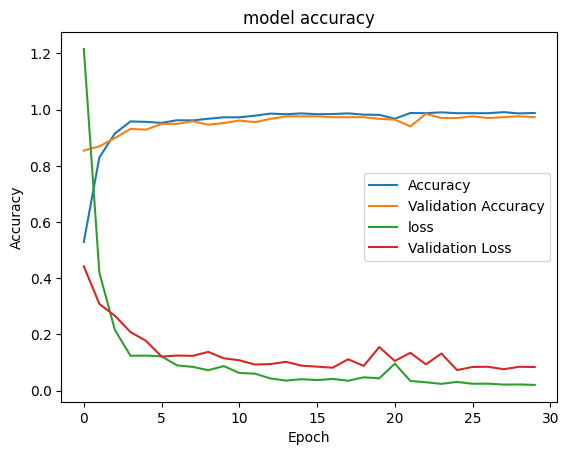

In [24]:
# Vẽ đồ thị
plt.plot(history.history["accuracy"])
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("model accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy","Validation Accuracy","loss","Validation Loss"])
plt.show()